In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent  # go up from dev_notebooks/
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)

Repo root: /home/lonce/working/agent_projects/FargoNDacoder


In [2]:
import random
import time
from datetime import datetime

In [3]:
import torch
import dac
import torch.optim as optim

#for tensorboard
import os
from torch.utils.tensorboard import SummaryWriter


from torch.utils.data import DataLoader
from utils.io import save_checkpoint, save_run_config

from core.rnndac_dataset import RNNDACLatentDataset, LatentDatasetConfig
from core.rnndac_model import GRUModelConfig, RNNDACModel#, RNNDACModelNoCascade

In [4]:
DEVICE = "cuda" #"cuda" if torch.cuda.is_available() else "cpu"

In [5]:
#Prepare DAC model
dac_model_path = dac.utils.download(model_type="44khz") 
print(f'Model is stored here: {dac_model_path}')
dac_model = dac.DAC.load(dac_model_path).to(DEVICE)


Model is stored here: /home/lonce/.cache/descript/dac/weights_44khz_8kbps_0.0.1.pth


/home/lonce/miniconda3/envs/synthformer/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [6]:
#PARAMETERS

In [7]:
# hf_dataset_path = "/slowdisk/data/DAC/pitchglidesATriangle5octaves/Aglides/hf_dataset"
# savename="inftest_glide_qwightloss_noisyinput_zeroedlatents0_condtoheads"
# testsetname="validation"
  
hf_dataset_path = "/slowdisk/data/DAC/waterfill/hf_dataset"
savename="waterfill_test_postOC_6_heavycondweight"
testsetname="test"

codebooklossraw = torch.tensor([1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6], dtype=torch.float)
qweights = codebooklossraw * (len(codebooklossraw) / codebooklossraw.sum())

zeroed_latent_proportion = 0.1 # slightly greater than zero was intended to force the model to pay attention to conditional values. 

params = {
    
    
    "n_steps": 7501,
    "print_every": 2000,
    "validate_every": 2000,

    # classification softmax temperature
    "tau": 0.4,

    # Inference sampling params
    "infer_top_k": 5,
    "infer_temperature": 0.5,
    "val_batches": 8,            # choose a small number like 2–8

    "checkpoint_every": 7500,

    "cond_injection": "concat",    # "concat", "film"
    "inp_proportion": 5,
    "cond_proportion": 2,


    "tf_schedule": [8000, 1000],

    # Inference sampling params
}


In [8]:
#Prepare output directories
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
savemodeldir = os.path.join(os.getcwd(), 'output')
out_dir = os.path.join(savemodeldir, run_timestamp + "_" + savename)
os.makedirs(out_dir, exist_ok=True)
os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
checkpoint_dir = os.path.join(out_dir, "checkpoints")
os.makedirs(f"{out_dir}/config", exist_ok=True)
config_dir = out_dir + "/config/"

print("out_dir:", out_dir)
print("checkpoint_dir :", checkpoint_dir )
print("config_dir:", config_dir)

#Prepare tensorboard
log_dir = os.path.join(out_dir, "tensorboard")
writer = SummaryWriter(log_dir=log_dir)
print("TensorBoard log dir:", log_dir)



# # ---- Create Output Folders ----
# if resume_checkpoint != None:
#     out_dir = resume_checkpoint
# else:
#     run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#     out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
#     os.makedirs(out_dir, exist_ok=True)

#     os.makedirs(out_dir, exist_ok=True)
#     os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
#     os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)

# save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
# print(f"wrote {out_dir}/config_v2.pt")

out_dir: /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260630_120429_waterfill_test_postOC_6_heavycondweight
checkpoint_dir : /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260630_120429_waterfill_test_postOC_6_heavycondweight/checkpoints
config_dir: /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260630_120429_waterfill_test_postOC_6_heavycondweight/config/
TensorBoard log dir: /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260630_120429_waterfill_test_postOC_6_heavycondweight/tensorboard


In [9]:
# Data set, Validation set, and Model configuration 


data_cfg = LatentDatasetConfig(
    dataset_path=hf_dataset_path,
    sequence_length=128,# 128,
    n_q=9,
    clamp_val=12,
    files_per_sequence=4, #4
    add_noise=True,
    noise_weight=0.05,
)

validation_cfg = LatentDatasetConfig(
    dataset_path=hf_dataset_path,
    sequence_length=128,
    n_q=9,
    clamp_val=12,
    files_per_sequence=1,
)


model_cfg = GRUModelConfig(
    n_q=9,
    codebook_size=1024,
    codebook_dim=8, #------------------------------------------
    input_size=72,
    cond_size=1,
    hidden_size=128, ####################128
    num_layers=3,   ####################3
    tau=params["tau"],
    cond_injection=params["cond_injection"],   # or "concat"
    inp_proportion=params["inp_proportion"],
    cond_proportion=params["cond_proportion"],    
)


In [10]:
#Create the RNN model
#model = RNNDACModel(cfg, codebook_vectors)
model = RNNDACModel(model_cfg, dac_model=dac_model)
#model = RNNDACModelNoCascade(model_cfg, dac_model=dac_model)
model = model.to(DEVICE)

In [11]:
#create dataset (training and validation)
ds = RNNDACLatentDataset(data_cfg, split="train", device="cpu")

loader = DataLoader(
    ds,
    batch_size=16, #8   # start small (was 4 for testing
    shuffle=True,
    num_workers=0   # keep 0 for notebooks / debugging
)


val_ds = RNNDACLatentDataset(validation_cfg, split=testsetname, device="cpu")
val_loader = DataLoader(val_ds, batch_size=params["val_batches"], shuffle=False, num_workers=0)


In [12]:
# Just run one batch -------------------------------

In [13]:
#grab one batch from the dataset
batch = next(iter(loader))
batch = {k: v.to(DEVICE) for k, v in batch.items()}

print(batch["latents"].shape)  # [B, T, n_q*8]
print(batch["targets"].shape)    # [B, T, n_q]
print(batch["cond"].shape)     # [B, T, p]

batch = {k: v.to(DEVICE) for k, v in batch.items()}

torch.Size([16, 128, 72])
torch.Size([16, 128, 9])
torch.Size([16, 128, 1])


In [14]:
# run a batch
out = model(
    latents=batch["latents"],                  # [B, T, 72]
    cond=batch["cond"],                        # [B, T, p]
    target_codes=batch["targets"],             # [B, T, n_q] for teacher forcing
    cascade_mode="free",
)



In [15]:

loss_dict = model.compute_loss(out["predicted_logits_per_codebook"], batch["targets"], qweights)
loss = loss_dict["total_loss"]


In [16]:
loss

tensor(62.4133, device='cuda:0', grad_fn=<SumBackward0>)

In [17]:
# Now run a short bunch of batches ----------------------------------------- 


In [18]:
model.train()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)


grad_clip = 1.0

train_loss_history = []
val_loss_history = []

train_iter = iter(loader)
val_iter = iter(val_loader)

# TF schedule: alternate between teacher and configured cascade
tf_on = params.get("tf_schedule", [0, 0])[0]
tf_off = params.get("tf_schedule", [0, 0])[1]
tf_cycle = tf_on + tf_off

for step in range(params["n_steps"]):
    # --------------------------------------------------
    # Training step
    # --------------------------------------------------
    try:
        batch = next(train_iter)
    except StopIteration:
        train_iter = iter(loader)
        batch = next(train_iter)

    batch = {k: v.to(DEVICE) for k, v in batch.items()}

    model.train()

    # Randomly zero latents to force cond usage (25% of steps)
    if random.random() < zeroed_latent_proportion:
        clean_latents = torch.zeros_like(batch["latents"])
    else:
        clean_latents = batch["latents"]
    
    # Determine training cascade for this step
    if tf_cycle > 0:
        in_tf_phase = (step % tf_cycle) < tf_on
        training_cascade = "teacher" if in_tf_phase else "free"
    else:
        training_cascade = "free"

    out = model(
        latents=clean_latents,
        cond=batch["cond"],
        target_codes=batch["targets"],
        cascade_mode=training_cascade,
    )

    loss_dict = model.compute_loss(
        out["predicted_logits_per_codebook"],
        batch["targets"],
        qweights
    )

    loss = loss_dict["total_loss"]
    per_q_losses = loss_dict["per_codebook_losses"]

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()

    train_loss_history.append(loss.item())

    # TensorBoard: training total + per-codebook
    writer.add_scalar("Loss/train_total", loss.item(), step)
    for q, q_loss in enumerate(per_q_losses):
        writer.add_scalar(f"Loss_train/codebook_{q}", q_loss.item(), step)

    # Print training stats
    if step % params["print_every"] == 0:
        recent = train_loss_history[-params["print_every"]:]
        avg_train_loss = sum(recent) / len(recent)
        print(f"time: {datetime.now()}, Step {step:4d} | Train Loss: {loss.item():.4f} | Train Avg: {avg_train_loss:.4f}")

    if step > 0 and step % params["checkpoint_every"] == 0:
        ckpt_path = save_checkpoint(
            output_dir=checkpoint_dir,
            step=step,
            model=model,
            optimizer=optimizer,
            params=params,
            model_config=model_cfg,
            data_config=data_cfg,
            extra={
                "last_train_loss": loss.item(),
                "train_loss_history_tail": train_loss_history[-10:],
            },
        )
        
        print(f"Saved checkpoint: {ckpt_path}")
    # --------------------------------------------------
    # Validation
    # --------------------------------------------------
    if step % params["validate_every"] == 0:
        model.eval()

        val_total_losses = []
        val_per_q_sums = [0.0 for _ in range(model.config.n_q)]

        with torch.no_grad():
            for _ in range(params["val_batches"]):
                try:
                    val_batch = next(val_iter)
                except StopIteration:
                    val_iter = iter(val_loader)
                    val_batch = next(val_iter)

                val_batch = {k: v.to(DEVICE) for k, v in val_batch.items()}

                val_out = model(
                    latents=val_batch["latents"],
                    cond=val_batch["cond"],
                    target_codes=val_batch["targets"],
                    cascade_mode="free",
                )

                val_loss_dict = model.compute_loss(
                    val_out["predicted_logits_per_codebook"],
                    val_batch["targets"],
                    qweights
                )

                val_total_losses.append(val_loss_dict["total_loss"].item())

                for q, q_loss in enumerate(val_loss_dict["per_codebook_losses"]):
                    val_per_q_sums[q] += q_loss.item()

        avg_val_loss = sum(val_total_losses) / len(val_total_losses)
        avg_val_per_q = [x / params["val_batches"] for x in val_per_q_sums]

        val_loss_history.append((step, avg_val_loss))

        # TensorBoard: validation total + per-codebook
        writer.add_scalar("Loss/val_total", avg_val_loss, step)
        for q, q_loss in enumerate(avg_val_per_q):
            writer.add_scalar(f"Loss_val/codebook_{q}", q_loss, step)

        print(f"           | Val Avg ({params['val_batches']} batches): {avg_val_loss:.4f}")

        model.train()

writer.flush()

time: 2026-06-30 12:04:31.322875, Step    0 | Train Loss: 64.9896 | Train Avg: 64.9896
           | Val Avg (8 batches): 64.6529
time: 2026-06-30 12:10:13.262503, Step 2000 | Train Loss: 40.5795 | Train Avg: 46.9687
           | Val Avg (8 batches): 62.4781
time: 2026-06-30 12:16:00.754544, Step 4000 | Train Loss: 50.4062 | Train Avg: 39.4366
           | Val Avg (8 batches): 67.4405
time: 2026-06-30 12:21:35.393806, Step 6000 | Train Loss: 33.9774 | Train Avg: 36.3211
           | Val Avg (8 batches): 69.8776
Saved checkpoint: /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260630_120429_waterfill_test_postOC_6_heavycondweight/checkpoints/checkpoints/step_007500.pt


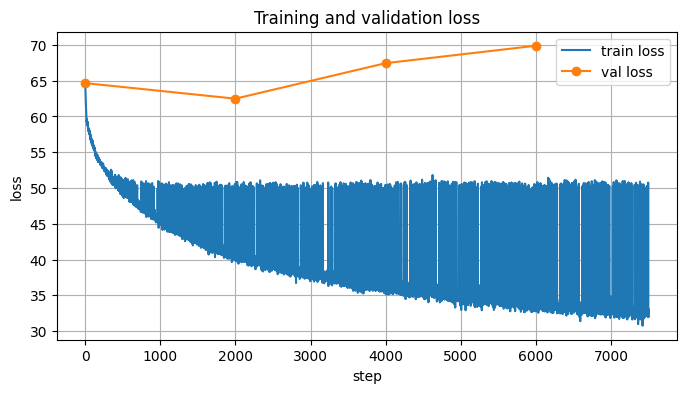

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label="train loss")

if val_loss_history:
    val_steps, val_vals = zip(*val_loss_history)
    plt.plot(val_steps, val_vals, "o-", label="val loss")

plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.grid(True)
plt.legend()
plt.show()

In [20]:
####### Prepare for Inference, test configuration and model loading #############

In [21]:
ckpt_path

PosixPath('/home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260630_120429_waterfill_test_postOC_6_heavycondweight/checkpoints/checkpoints/step_007500.pt')

In [22]:
print(f'About to load {ckpt_path}')
saved_configs = torch.load(ckpt_path, weights_only=False)

model_config = GRUModelConfig(**saved_configs["model_config"])
data_config = LatentDatasetConfig(**saved_configs["data_config"])
params = saved_configs["params"]

# Inference defaults (override old checkpoint defaults with safe values)
params.setdefault("infer_top_k", 5)
params.setdefault("infer_temperature", 0.5)

About to load /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260630_120429_waterfill_test_postOC_6_heavycondweight/checkpoints/checkpoints/step_007500.pt


0.5

In [23]:
model = RNNDACModel(model_config, dac_model=dac_model)
ckpt = torch.load(ckpt_path, weights_only=False, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

RNNDACModel(
  (latent_proj): Linear(in_features=72, out_features=91, bias=True)
  (cond_proj): Linear(in_features=1, out_features=37, bias=True)
  (gru): GRU(128, 128, num_layers=3, batch_first=True, dropout=0.1)
  (heads): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): Linear(in_features=136, out_features=1024, bias=True)
    (2): Linear(in_features=144, out_features=1024, bias=True)
    (3): Linear(in_features=152, out_features=1024, bias=True)
    (4): Linear(in_features=160, out_features=1024, bias=True)
    (5): Linear(in_features=168, out_features=1024, bias=True)
    (6): Linear(in_features=176, out_features=1024, bias=True)
    (7): Linear(in_features=184, out_features=1024, bias=True)
    (8): Linear(in_features=192, out_features=1024, bias=True)
  )
  (rnn_dropout): Identity()
)

In [24]:
# Actually do some inference (using the chunk+hopoe+lookahead strategy)

In [25]:
listen_loader = DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=0)
listen_batch = next(iter(listen_loader))
listen_batch = {k: v.to(DEVICE) for k, v in listen_batch.items()}

print(listen_batch["latents"].shape)   # [1, T, 72]
print(listen_batch["targets"].shape)   # [1, T, 9]
print(listen_batch["cond"].shape)      # [1, T, p]

torch.Size([1, 128, 72])
torch.Size([1, 128, 9])
torch.Size([1, 128, 1])


In [26]:
model.eval()
model=model.to(DEVICE)

In [27]:
# import importlib
# import core.inference
# importlib.reload(core.inference)


# Build code pool from training set to constrain CB0 sampling
from core.inference import build_code_pool
pool = build_code_pool(ds, n_bins=100, cond_index=0, n_q_for_pool=1)
n_total = sum(len(pool[b][0]) for b in range(len(pool)))
n_bins_with_codes = sum(1 for b in range(len(pool)) if pool[b][0])
print(f"Pool: {n_bins_with_codes}/{len(pool)} bins have codes, "
      f"{n_total} total (bin,code) pairs")


Pool: 100/100 bins have codes, 200 total (bin,code) pairs


=== Pool summary ===
  Active bins:         95/100
  Total vectors stored:   3200
  Unique CB0 codes across all bins: 270 / 1024
  Coverage:            26.4% of codebook
  Vectors per bin:      min=0, max=76, mean=33.7



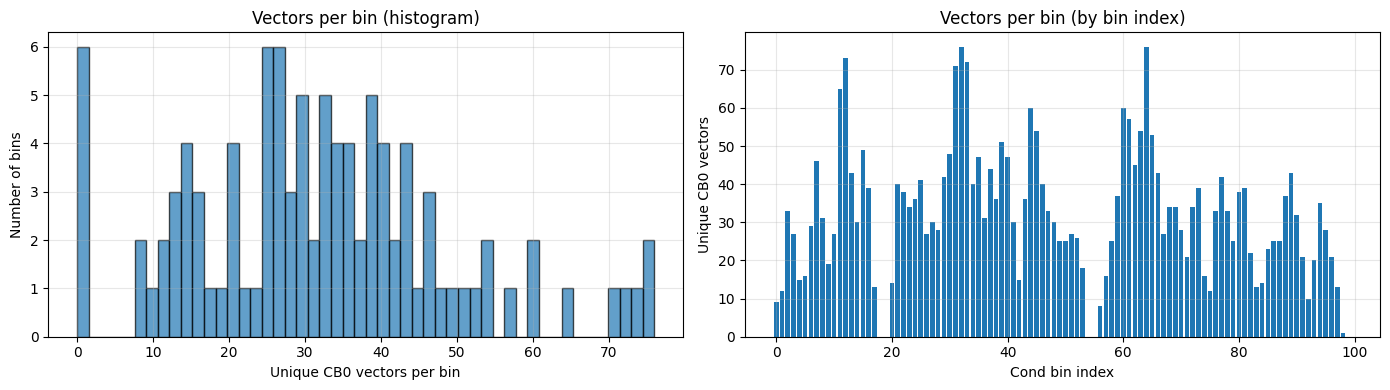

=== Intra-bin cosine similarity (CB0 vectors) ===
  Bins with >=2 vectors analyzed: 94
  Mean intra-bin cosine sim:   0.2421 +- 0.0725
  (1.0 = identical, 0.0 = orthogonal, -1.0 = opposite)

Example bins:
  bin   0 (cond~0.00): 9 vectors, sim mean=0.291  range=[0.000, 0.890]
  bin  24 (cond~0.24): 36 vectors, sim mean=0.098  range=[-0.731, 0.994]
  bin  49 (cond~0.49): 25 vectors, sim mean=0.261  range=[-0.405, 0.987]
  bin  74 (cond~0.74): 16 vectors, sim mean=0.252  range=[-0.202, 0.990]
  bin  99 (cond~0.99): 0 vector(s) -- too few to pair



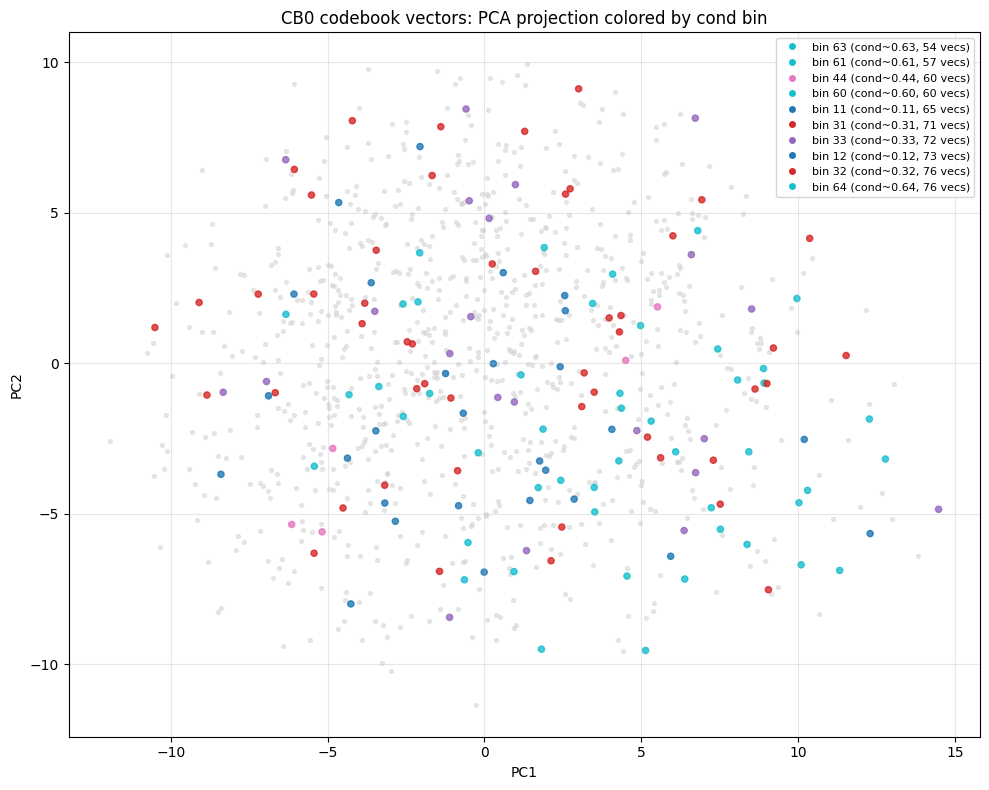

In [28]:
# import importlib
# import core.inference, core.pool_diagnostics
# importlib.reload(core.inference)
# importlib.reload(core.pool_diagnostics)
from core.inference import build_code_pool
from core.pool_diagnostics import pool_summary, intra_bin_distances, plot_pool_projections


from core.pool_diagnostics import pool_summary, intra_bin_distances, plot_pool_projections

stats = pool_summary(pool, model)
sim = intra_bin_distances(pool, model, n_example_bins=5)
plot_pool_projections(pool, model, max_bins_to_color=10)


In [29]:
from core.inference import infer_streaming_with_lookahead

#cvect = listen_batch["cond"]
print("DEVICE:", DEVICE)
cvect = torch.linspace(.05, .95, 900).unsqueeze(0).unsqueeze(-1)  # shape [1, 300, 1]
cvect=cvect.to(DEVICE)
print("cond_sequence device:", cvect.device)

print("model param device:", next(model.parameters()).device)
print("codebook buffer device:", model.codebook_vectors.device)
print("dac model param device:", next(dac_model.parameters()).device)
print("cond_sequence device:", cvect.device)

DEVICE: cuda
cond_sequence device: cuda:0
model param device: cuda:0
codebook buffer device: cuda:0
dac model param device: cuda:0
cond_sequence device: cuda:0


In [92]:
import time
t0 = time.time()


with torch.no_grad():
    gen_audio = infer_streaming_with_lookahead(
        rnn_model=model,
        dac_model=dac_model,
        cond_sequence=cvect,   # [1, T, p]
        chunk_size=16,
        hop_size=1,
        right_context=4,
        frame_samples=512,
        tau=params["infer_temperature"],
        top_k=params["infer_top_k"],
        #pool=pool,  #Better with out pool selection!!
    )

print(f"{time.time() - t0:.4f}s")
print(f"conditioning shape: {cvect.shape}")
print(f"Audio shape: {gen_audio.shape}")
print(f" T*512 = {cvect.shape[1]*512}")

3.8663s
conditioning shape: torch.Size([1, 900, 1])
Audio shape: torch.Size([1, 1, 460800])
 T*512 = 460800


In [93]:
import IPython.display as ipd
gen_audio_np = gen_audio.squeeze().detach().cpu().numpy()
ipd.display(ipd.Audio(6*gen_audio_np, rate=44100))

In [32]:
#----------------------------------------------------------

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_audio_with_params_two_yaxes(
    trialaudio,
    whole_param_seq,
    audio_sr=24000,
    param_sr=75,
    param_names=None,
    figsize=(14, 4),
    audio_pad_frac=0.08,
    audio_pad_abs=1e-3,
    param_pad_frac=0.05,   # NEW
    title="RNeNcodec parameter-driven synthesis",
    subtitle=""
):
    color1 = '#AAAAAA'
    colors = ['#AA0022', 'tab:orange', 'tab:green', 'tab:purple', 'tab:brown',
              'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']

    if hasattr(whole_param_seq, "detach"):
        whole_param_seq = whole_param_seq.detach().cpu().numpy()

    trialaudio = np.asarray(trialaudio).squeeze()
    whole_param_seq = np.asarray(whole_param_seq)

    N = trialaudio.shape[0]
    T, D = whole_param_seq.shape

    t_audio = np.arange(N) / audio_sr
    t_param = np.arange(T) / param_sr

    fig, ax_audio = plt.subplots(figsize=figsize)

    # ---- Audio axis ----
    ax_audio.plot(t_audio, trialaudio, color=color1, linewidth=0.6, alpha=0.85, label="audio")
    ax_audio.set_xlabel("Time (seconds)")
    ax_audio.set_ylabel("Audio amplitude")
    ax_audio.grid(True, alpha=0.25)

    a_min = float(np.min(trialaudio))
    a_max = float(np.max(trialaudio))
    a_rng = a_max - a_min

    pad = max(audio_pad_abs, audio_pad_frac * (a_rng if a_rng > 0 else 1.0))
    y0 = a_min - pad
    y1 = a_max + pad

    if not np.isfinite(y0) or not np.isfinite(y1) or abs(y1 - y0) < 1e-6:
        y0, y1 = -0.1, 0.1

    ax_audio.set_ylim(y0, y1)

    # ---- Parameter mapping with visual padding ----
    # Parameter *visual* range
    p_lo = -param_pad_frac
    p_hi = 1.0 + param_pad_frac
    p_span = p_hi - p_lo

    y_span = y1 - y0

    # Map param values into audio y-range using padded param space
    params_in_audio_units = y0 + (whole_param_seq - p_lo) / p_span * y_span

    for d in range(D):
        c = colors[d % len(colors)]
        label = param_names[d] if (param_names is not None and d < len(param_names)) else f"param {d}"
        ax_audio.plot(
            t_param,
            params_in_audio_units[:, d],
            color=c,
            linewidth=2.0,
            alpha=0.95,
            label=label
        )

    # ---- Right axis: padded parameter scale ----
    ax_param = ax_audio.twinx()
    ax_param.set_ylabel("Parameter value")

    # Nice ticks in parameter space (still centered on [0,1])
    p_ticks = np.linspace(0, 1, 6)
    y_ticks = y0 + (p_ticks - p_lo) / p_span * y_span

    ax_param.set_ylim(y0, y1)
    ax_param.set_yticks(y_ticks)
    ax_param.set_yticklabels([f"{p:.1f}" for p in p_ticks])

    ax_audio.legend(loc="upper right", frameon=False)

    if title is not None:
        ax_audio.set_title(title + "\n" + subtitle)

    plt.tight_layout()
    plt.show()


In [34]:
cvect.shape

torch.Size([1, 900, 1])

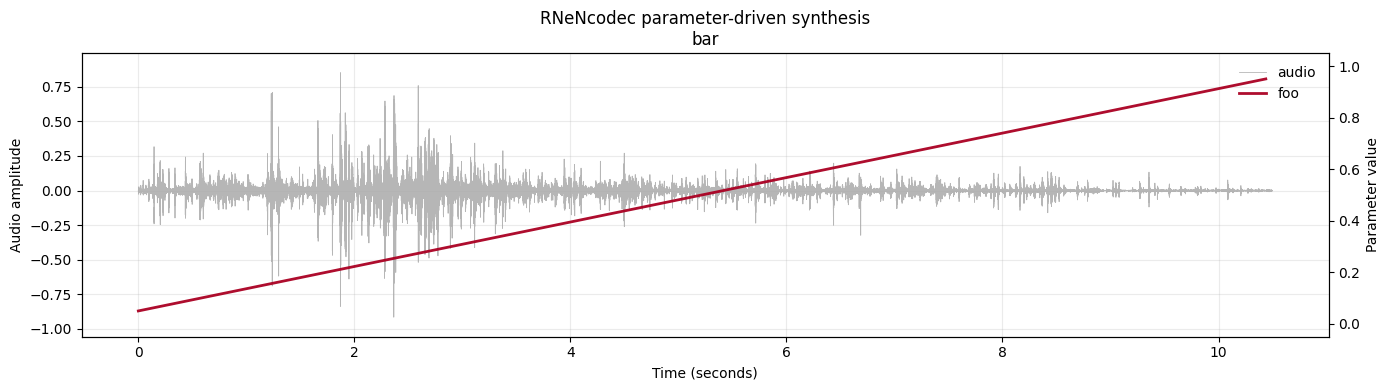

In [35]:
plot_audio_with_params_two_yaxes(
    gen_audio_np,
    cvect.squeeze(0),
    audio_sr=44100,
    param_sr=86.13,
    param_names=["foo"], 
    subtitle="bar"
)

Frames with valid pitch: 839 / 900
Pearson R: 0.1064  (p=0.0020)
Pitch R²:  0.0113


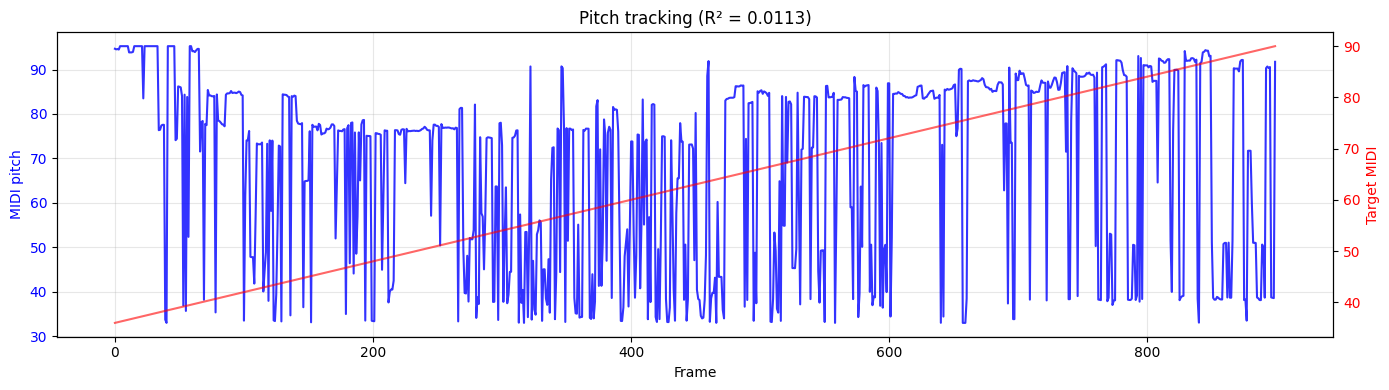

In [37]:
# --- Pitch extraction via librosa.yin ---
import librosa
import numpy as np
from scipy.stats import pearsonr

# Extract pitch from generated audio
audio_np = gen_audio.squeeze().detach().cpu().numpy()
sr = 44100
f0 = librosa.yin(audio_np, fmin=55, fmax=2000, sr=sr)

cond_np = cvect.squeeze().cpu().numpy()  # [900] numpy array, range [0.05, 0.95]

midi = 69 + 12 * np.log2(np.clip(f0, 1e-3, None) / 440.0)
cond_midi = cond_np * (93 - 33) + 33  # denormalize cond for interpretability
midi = midi[:len(cond_np)]

mask = (midi >= 33) & (midi <= 93) & np.isfinite(midi)
print(f"Frames with valid pitch: {mask.sum()} / {len(mask)}")

if mask.sum() > 5:
    r, pval = pearsonr(cond_np[mask], 
                        (midi[mask] - 33) / (93 - 33))
    print(f"Pearson R: {r:.4f}  (p={pval:.4f})")
    print(f"Pitch R²:  {r**2:.4f}")
    title = f"Pitch tracking (R² = {r**2:.4f})"
else:
    print("Too few pitched frames")
    title = "Pitch tracking (insufficient pitch)"

fig, ax1 = plt.subplots(figsize=(14, 4))
t_ax = np.arange(len(cond_np))
ax1.plot(t_ax, midi, "b-", label="Extracted MIDI", alpha=0.8)
ax1.set_ylabel("MIDI pitch", color="b")
ax1.tick_params(axis="y", labelcolor="b")

ax2 = ax1.twinx()
ax2.plot(t_ax, cond_midi, "r-", label="Target MIDI", alpha=0.6)
ax2.set_ylabel("Target MIDI", color="r")
ax2.tick_params(axis="y", labelcolor="r")
ax1.set_xlabel("Frame")
ax1.set_title(title)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [61]:
# Cell A: Setup
%gui tk
import sys
sys.path.insert(0, "/home/lonce/working/agent_projects/FargoNDacoder")
from rtplayer import SynthWidget

model.eval()
for p in model.parameters():
    p.requires_grad_(False)

In [94]:
# Cell B: Launch widget
widget = SynthWidget(
    param_names=["fill level"],
    initial_values=[0.5],
    rnn_model=model,
    dac_model=dac_model,
    backend="aplay",
    # target_buffer_ms=500,
)